# Three Binary Baseline Classifiers on full images

This notebook trains the first three **full-image + metadata** classifiers as **binary classification** tasks:

1. **Sagittal T2/STIR** → Spinal Canal Stenosis  
2. **Sagittal T1** → Neural Foraminal Narrowing  
3. **Axial T2** → Subarticular Stenosis  

Target definition:

```text
Normal/Mild       -> 0 = no_stenosis
Moderate, Severe  -> 1 = stenosis
```

The input format is corrected for MRI:
- DICOM grayscale is loaded directly from `img_path`.
- Intensities are clipped using percentiles and normalized to `[0, 1]`.
- The grayscale image is repeated into **3 identical channels** for ImageNet-compatible CNNs.
- Mean and standard deviation are computed from the **training data only**.
- ResNet34 can be trained either with ImageNet-pretrained weights or from scratch.


## 1. Imports

In [2]:
# IMPORTS
import os
import re
import copy
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    log_loss,
)

from tqdm.auto import tqdm


## 2. Reproducibility and configuration

In [3]:
# SET SEED FOR REPRODUCIBILITY
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

In [4]:
# ----------------------------
# CONFIG
# ----------------------------
import os

ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
PROJECT_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline")
DATA_CSV = DATA_ROOT / "data-rsna2024" / "data_merged.csv"
os.chdir(ROOT)

# Output folder for trained models and results.
MODEL_ROOT_DIR = Path("models")
RUN_NAME = "models_baseline_binary_medical"

OUTPUT_DIR = MODEL_ROOT_DIR / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Transfer learning is recommended for this limited medical-imaging setup.
PRETRAINED = True

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Early stopping is allowed only after MIN_EPOCHS.
# These values are less aggressive than the previous recall-only setting.
EPOCHS = 50
MIN_EPOCHS = 15
PATIENCE = 6
MIN_DELTA = 1e-4

LR = 1e-4
BACKBONE_LR_MULTIPLIER = 0.1
WEIGHT_DECAY = 1e-4

# DataLoader performance settings.
# Keep NUM_WORKERS > 0 for speed. persistent_workers reduces repeated worker cleanup.
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

# Model-head regularization.
HIDDEN_DIM = 512
DROPOUT = 0.15

# Class imbalance and recall-prioritization controls.
# Start with weaker imbalance pressure; increase only if stenosis recall is too low.
RECALL_WEIGHT_MULTIPLIER = 1.2
USE_WEIGHTED_SAMPLER = False
LABEL_SMOOTHING = 0.0
GRAD_CLIP_NORM = 1.0

# Threshold tuning: require at least this positive-class precision when maximizing recall.
MIN_PRECISION_FOR_THRESHOLD = 0.20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def dataloader_worker_kwargs(num_workers=NUM_WORKERS):
    """Return DataLoader worker-related kwargs that are valid for the chosen num_workers."""
    kwargs = {
        "num_workers": num_workers,
        "pin_memory": PIN_MEMORY,
    }

    if num_workers > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
        kwargs["prefetch_factor"] = PREFETCH_FACTOR

    return kwargs


print("Using device:", DEVICE)
print("Project root:", PROJECT_ROOT)
print("Data CSV:", DATA_CSV)
print("Output dir:", OUTPUT_DIR)
print("NUM_WORKERS:", NUM_WORKERS)


Using device: cuda
Project root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline
Data CSV: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024/data_merged.csv
Output dir: models/models_baseline_binary_medical
NUM_WORKERS: 4


## 3. Load and prepare dataframe

This section creates:

- `base_condition`: condition without left/right prefix
- `side`: `center`, `left`, or `right`
- `target`: binary label where `0 = no_stenosis` and `1 = stenosis`

For this binary setup, `Normal/Mild` is treated as no stenosis, while `Moderate` and `Severe` are treated as stenosis.


In [5]:
# LABEL DEFINITIONS
# Binary target:
#   0 = no stenosis      (Normal/Mild)
#   1 = stenosis         (Moderate or Severe)

data_merged = pd.read_csv(DATA_CSV)

BINARY_SEVERITY_MAP = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 1,
}

N_CLASSES = 2
TARGET_NAMES = ["no_stenosis", "stenosis"]

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SIDE_TO_ID = {
    "center": 0,
    "left": 1,
    "right": 2,
}

SERIES_TO_ID = {
    "Sagittal T2/STIR": 0,
    "Sagittal T1": 1,
    "Axial T2": 2,
}

LEVEL_TO_ID = {level: idx for idx, level in enumerate(LEVELS)}


def extract_side(condition):
    condition = str(condition).lower()

    if condition.startswith("left"):
        return "left"
    elif condition.startswith("right"):
        return "right"
    else:
        return "center"


def extract_base_condition(condition):
    condition = str(condition)
    return (
        condition
        .replace("Left ", "")
        .replace("Right ", "")
    )


data_merged["side"] = data_merged["condition"].apply(extract_side)
data_merged["base_condition"] = data_merged["condition"].apply(extract_base_condition)

# Keep original severity as text, but train using binary target.
data_merged["target"] = data_merged["severity"].map(BINARY_SEVERITY_MAP)


data_merged = data_merged.dropna(subset=[
    "study_id",
    "img_path",
    "target",
    "level",
    "side",
    "series_description",
]).copy()

data_merged["target"] = data_merged["target"].astype(int)

print("Base condition distribution:")
print(data_merged["base_condition"].value_counts())
print("==========================")
print("Series distribution:")
print(data_merged["series_description"].value_counts())
print("==========================")
print("Binary target distribution:")
print(data_merged["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))


Base condition distribution:
base_condition
Neural Foraminal Narrowing    19689
Subarticular Stenosis         19215
Spinal Canal Stenosis          9753
Name: count, dtype: int64
Series distribution:
series_description
Sagittal T1         19694
Axial T2            19215
Sagittal T2/STIR     9748
Name: count, dtype: int64
Binary target distribution:
target
no_stenosis    37626
stenosis       11031
Name: count, dtype: int64


## 4. Study-level train/validation/test split
Split is created by `study_id`, which prevents patient/study leakage.

In [6]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

# First split: train vs temporary validation + test
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    gss1.split(
        data_merged,
        groups=data_merged["study_id"],
    )
)

train_df = data_merged.iloc[train_idx].copy()
temp_df = data_merged.iloc[temp_idx].copy()

# Second split: validation vs test from the temporary set
val_relative_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=val_relative_size,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["study_id"],
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Rows:")
print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

print("\nUnique studies:")
print("train:", train_df["study_id"].nunique())
print("val:  ", val_df["study_id"].nunique())
print("test: ", test_df["study_id"].nunique())

Rows:
train: (34045, 14)
val:   (7289, 14)
test:  (7323, 14)

Unique studies:
train: 1381
val:   296
test:  297


In [7]:
# Cell 1: prepare merged dataframe
plot_df = pd.concat(
    [
        train_df[["condition", "base_condition", "severity"]].assign(split="train"),
        val_df[["condition", "base_condition", "severity"]].assign(split="val"),
        test_df[["condition", "base_condition", "severity"]].assign(split="test"),
    ],
    ignore_index=True,
)

plot_df["condition_plot"] = plot_df["base_condition"]

plot_df.loc[
    plot_df["condition"].str.contains("Left Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Left Neural Foraminal Narrowing"

plot_df.loc[
    plot_df["condition"].str.contains("Right Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Right Neural Foraminal Narrowing"

severity_order = ["Normal/Mild", "Moderate", "Severe"]
split_order = ["train", "val", "test"]

plot_df["severity"] = pd.Categorical(plot_df["severity"], categories=severity_order, ordered=True)
plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)

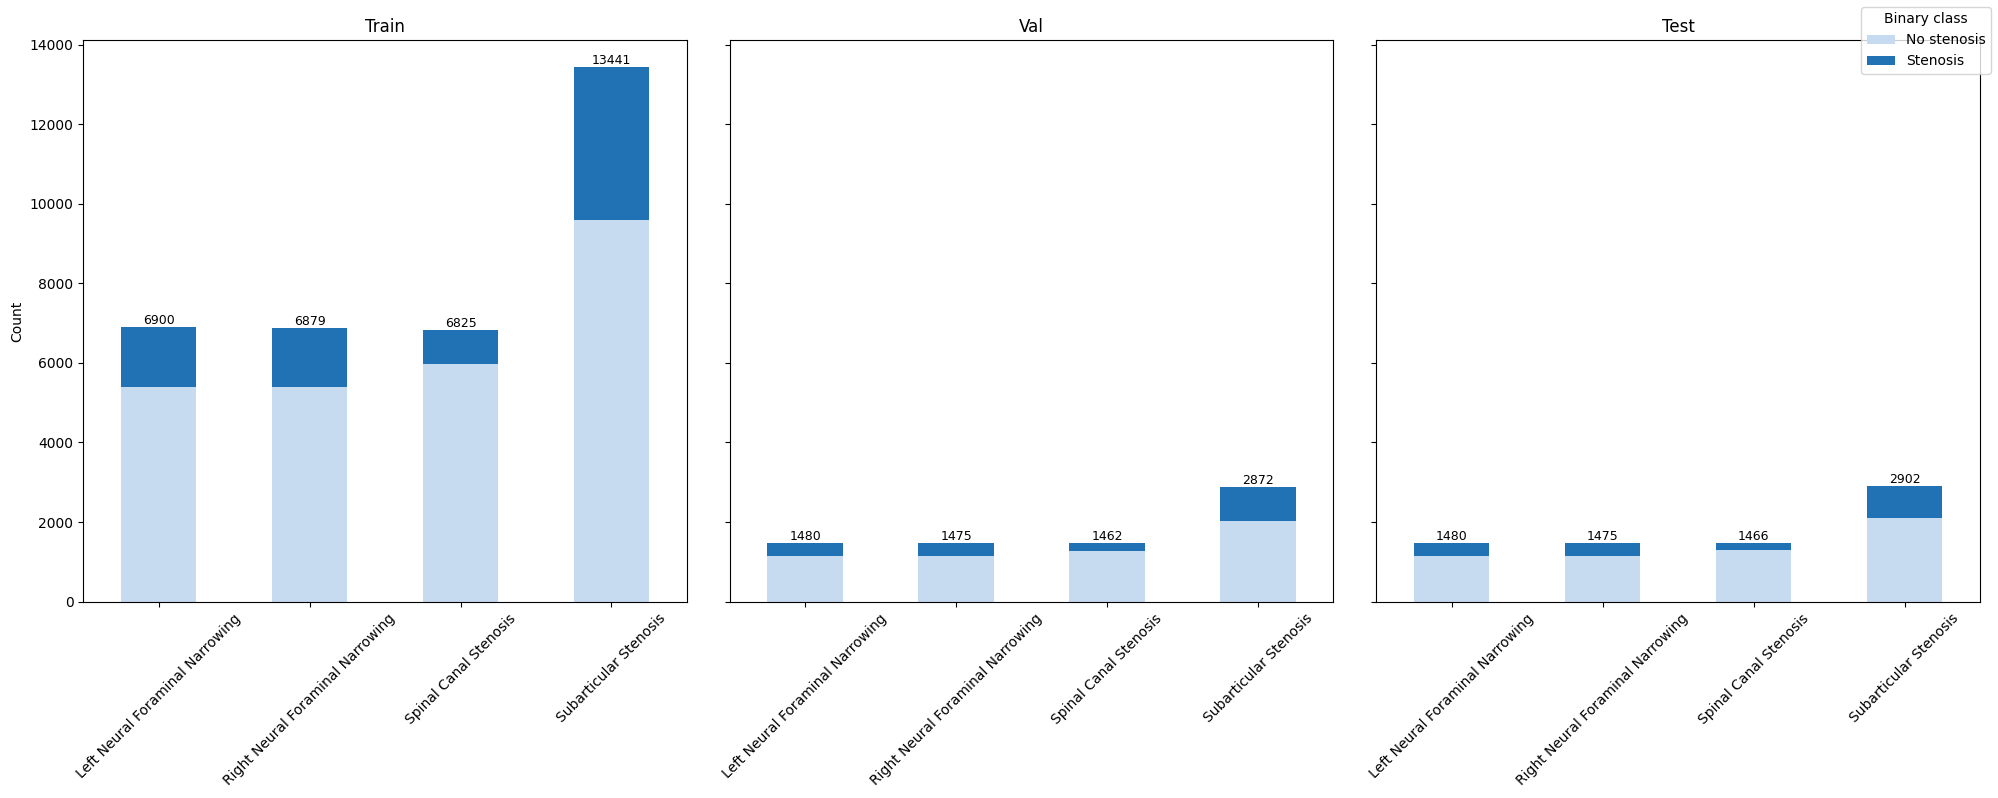

In [8]:
# Cell 2: side-by-side stacked bar charts with total counts for binary target

import matplotlib.pyplot as plt

# Create binary label for plotting
plot_df["stenosis_binary"] = plot_df["severity"].map({
    "Normal/Mild": "No stenosis",
    "Moderate": "Stenosis",
    "Severe": "Stenosis",
})

binary_order = ["No stenosis", "Stenosis"]
condition_order = sorted(plot_df["condition_plot"].dropna().unique())

blue_colors = ["#c6dbef", "#2171b5"]

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

for ax, split in zip(axes, split_order):
    split_counts = pd.crosstab(
        plot_df.loc[plot_df["split"] == split, "condition_plot"],
        plot_df.loc[plot_df["split"] == split, "stenosis_binary"]
    ).reindex(index=condition_order, columns=binary_order, fill_value=0)

    split_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False,
        color=blue_colors
    )

    totals = split_counts.sum(axis=1)

    for i, total in enumerate(totals):
        ax.text(
            i,
            total,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{split.capitalize()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Count")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Binary class", loc="upper right")

plt.tight_layout()
plt.show()

## 5. Define the three classifiers

Each model is trained on the matching sequence and condition.

In [9]:
MODEL_CONFIGS = {
    "spinal_canal_stenosis": {
        "base_condition": "Spinal Canal Stenosis",
        "series_description": "Sagittal T2/STIR",
    },
    "neural_foraminal_narrowing": {
        "base_condition": "Neural Foraminal Narrowing",
        "series_description": "Sagittal T1",
    },
    "subarticular_stenosis": {
        "base_condition": "Subarticular Stenosis",
        "series_description": "Axial T2",
    },
}


def make_model_df(df, base_condition, series_description):
    out = df[
        (df["base_condition"] == base_condition) &
        (df["series_description"] == series_description)
    ].copy()

    out = out.dropna(subset=[
        "img_path",
        "target",
        "level",
        "side",
        "series_description",
    ])

    return out.reset_index(drop=True)


model_dfs = {}

for model_name, cfg in MODEL_CONFIGS.items():
    model_dfs[model_name] = {
        "train": make_model_df(train_df, cfg["base_condition"], cfg["series_description"]),
        "val": make_model_df(val_df, cfg["base_condition"], cfg["series_description"]),
        "test": make_model_df(test_df, cfg["base_condition"], cfg["series_description"]),
    }

for model_name, parts in model_dfs.items():
    print("\n", model_name)
    for split_name, split_df in parts.items():
        print(f"{split_name:5s}: {len(split_df):6d} rows | {split_df['study_id'].nunique():4d} studies")
        print(split_df["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))


 spinal_canal_stenosis
train:   6820 rows | 1380 studies
target
no_stenosis    5964
stenosis        856
Name: count, dtype: int64
val  :   1462 rows |  296 studies
target
no_stenosis    1282
stenosis        180
Name: count, dtype: int64
test :   1466 rows |  297 studies
target
no_stenosis    1303
stenosis        163
Name: count, dtype: int64

 neural_foraminal_narrowing
train:  13779 rows | 1380 studies
target
no_stenosis    10800
stenosis        2979
Name: count, dtype: int64
val  :   2955 rows |  296 studies
target
no_stenosis    2280
stenosis        675
Name: count, dtype: int64
test :   2955 rows |  296 studies
target
no_stenosis    2275
stenosis        680
Name: count, dtype: int64

 subarticular_stenosis
train:  13441 rows | 1381 studies
target
no_stenosis    9601
stenosis       3840
Name: count, dtype: int64
val  :   2872 rows |  296 studies
target
no_stenosis    2028
stenosis        844
Name: count, dtype: int64
test :   2902 rows |  297 studies
target
no_stenosis    2090
sten

## 6. Create dataset

The dataset returns:

```text
image tensor, metadata dictionary, binary target label
```

Binary target: `0 = no_stenosis`, `1 = stenosis`.


In [10]:
def read_dicom_array(path, clip_percentiles=(1, 99)):
    """Read one DICOM image and return a normalized float32 grayscale array in [0, 1]."""
    ds = pydicom.dcmread(path)

    img = ds.pixel_array.astype(np.float32)

    # Correct display inversion for MONOCHROME1.
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    # Robust clipping reduces the influence of extreme values.
    low, high = np.percentile(img, clip_percentiles)
    if high > low:
        img = np.clip(img, low, high)

    # Normalize to [0, 1].
    img = img - img.min()
    denom = img.max()
    if denom > 0:
        img = img / denom

    return img.astype(np.float32)

def read_dicom_as_pil_grayscale(path):
    """Read DICOM and convert to PIL grayscale image."""
    img = read_dicom_array(path)
    img_uint8 = (img * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(img_uint8).convert("L")

In [11]:
class LumbarMetadataClassificationDataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        augmentation_transform=None,
        augment=False,
        level_to_id=None,
        side_to_id=None,
        series_to_id=None,
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.augmentation_transform = augmentation_transform
        self.augment = augment

        self.level_to_id = level_to_id if level_to_id is not None else LEVEL_TO_ID
        self.side_to_id = side_to_id if side_to_id is not None else SIDE_TO_ID
        self.series_to_id = series_to_id if series_to_id is not None else SERIES_TO_ID

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = read_dicom_as_pil_grayscale(row["img_path"])

        # Apply stochastic data augmentation only for the training dataset.
        # The augmentation is applied before tensor conversion/normalization.
        if self.augment and self.augmentation_transform is not None:
            image = self.augmentation_transform(image)

        if self.transform is not None:
            image = self.transform(image)

        metadata = {
            "level": torch.tensor(self.level_to_id[row["level"]], dtype=torch.long),
            "side": torch.tensor(self.side_to_id[row["side"]], dtype=torch.long),
            "series": torch.tensor(self.series_to_id[row["series_description"]], dtype=torch.long),
        }

        target = torch.tensor(int(row["target"]), dtype=torch.long)

        return image, metadata, target


## 8. Compute mean and standard deviation from training data only

This replaces the old mean/std values that were computed on another dataset.

Default: compute one global mean/std from all three model training subsets.  
This keeps preprocessing consistent across the three classifiers.

In [12]:
# Transform used only for mean/std calculation.
# No normalization here.
mean_std_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])


@torch.no_grad()
def compute_mean_std(df, batch_size=32, num_workers=NUM_WORKERS):
    dataset = LumbarMetadataClassificationDataset(
        df,
        transform=mean_std_transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        **dataloader_worker_kwargs(num_workers),
    )

    channel_sum = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    num_pixels = 0

    for images, metadata, targets in tqdm(loader, desc="Computing mean/std"):
        # images shape: [B, C, H, W]
        images = images.float()
        b, c, h, w = images.shape

        channel_sum += images.sum(dim=(0, 2, 3))
        channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))
        num_pixels += b * h * w

    mean = channel_sum / num_pixels
    variance = channel_sum_sq / num_pixels - mean ** 2
    std = torch.sqrt(torch.clamp(variance, min=1e-8))

    return mean.tolist(), std.tolist()


# Combine only TRAINING rows from the three classifiers.
norm_train_df = pd.concat(
    [model_dfs[name]["train"] for name in MODEL_CONFIGS.keys()],
    axis=0,
    ignore_index=True,
).drop_duplicates(subset=["img_path", "level", "side", "base_condition"])

print("Rows used for mean/std:", len(norm_train_df))

mean, std = compute_mean_std(
    norm_train_df,
    batch_size=32,
    num_workers=NUM_WORKERS,
)

print("Computed mean:", mean)
print("Computed std: ", std)

# Save for reproducibility.
pd.DataFrame({"mean": mean, "std": std}).to_csv(OUTPUT_DIR / "computed_train_mean_std.csv", index=False)


Rows used for mean/std: 34040


Computing mean/std:   0%|          | 0/1064 [00:00<?, ?it/s]

Computed mean: [0.22406505048274994, 0.22406505048274994, 0.22406505048274994]
Computed std:  [0.25239378213882446, 0.25239378213882446, 0.25239378213882446]


## 9. Transforms

The image remains grayscale MRI information, but is repeated into three channels for ResNet34 compatibility.

In [13]:
# TRANSFORMS
# Grayscale(num_output_channels=3) creates [gray, gray, gray].
#
# Medical MRI augmentation strategy:
# - small affine changes simulate imperfect positioning/slice orientation;
# - mild brightness/contrast changes simulate scanner/intensity variability;
# - occasional blur simulates small acquisition or interpolation differences.
#
# Important: horizontal flipping is intentionally NOT used by default because
# foraminal stenosis has left/right metadata. A horizontal flip would swap left
# and right anatomy unless the side label was also changed.

USE_DATA_AUGMENTATION = True

train_augmentation = transforms.Compose([
    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0,
    ),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
        )
    ], p=0.50),
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8),
        )
    ], p=0.15),
])

# Deterministic preprocessing used after optional augmentation.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])


## 10. Visual sanity check

This confirms that the dataset loads DICOMs correctly and that labels/metadata are valid.

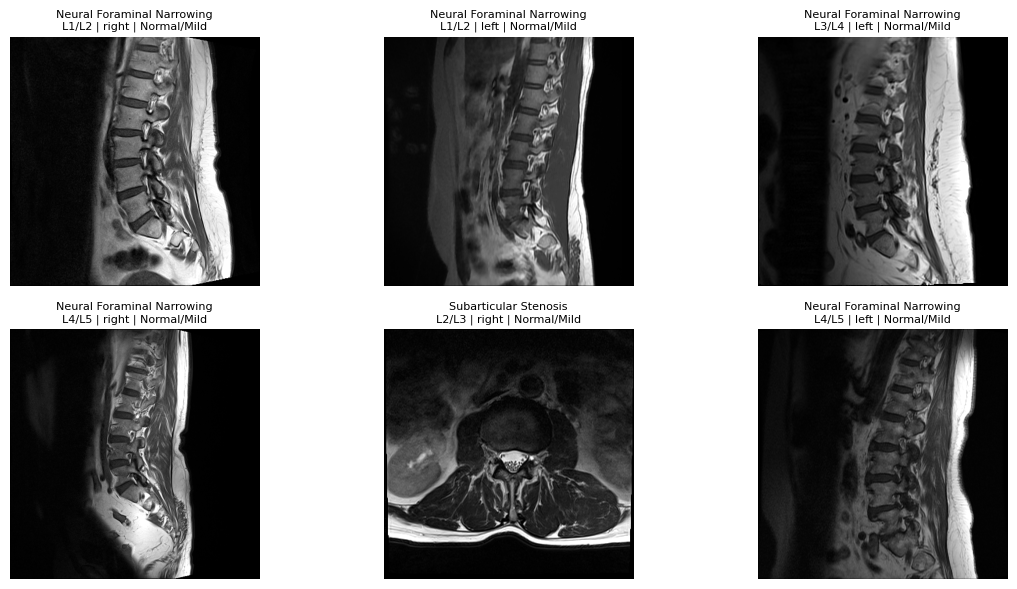

In [14]:
# VISUAL SANITY CHECK BEFORE NORMALIZATION
sample_df = norm_train_df.sample(min(6, len(norm_train_df)), random_state=42)

plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = read_dicom_array(row["img_path"])

    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(
        f"{row['base_condition']}\n"
        f"{row['level']} | {row['side']} | {row['severity']}",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## 11. Image + metadata ResNet34 model

The CNN extracts image features.  
Metadata embeddings for `level`, `side`, and `series_description` are concatenated with image features before classification.

In [15]:
class ResNet34MetadataClassifier(nn.Module):
    def __init__(
        self,
        n_levels=5,
        n_sides=3,
        n_series=3,
        n_classes=N_CLASSES,
        pretrained=True,
        level_emb_dim=8,
        side_emb_dim=4,
        series_emb_dim=4,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        if pretrained:
            weights = models.ResNet34_Weights.IMAGENET1K_V1
        else:
            weights = None

        self.backbone = models.resnet34(weights=weights)

        image_feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.level_emb = nn.Embedding(n_levels, level_emb_dim)
        self.side_emb = nn.Embedding(n_sides, side_emb_dim)
        self.series_emb = nn.Embedding(n_series, series_emb_dim)

        metadata_dim = level_emb_dim + side_emb_dim + series_emb_dim
        input_dim = image_feature_dim + metadata_dim

        # LayerNorm is used instead of BatchNorm1d because the final training batch
        # can occasionally contain one sample. BatchNorm1d crashes with batch size 1.
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),

            nn.Linear(hidden_dim // 2, n_classes),
        )

    def forward(self, images, metadata):
        image_features = self.backbone(images)

        level_features = self.level_emb(metadata["level"])
        side_features = self.side_emb(metadata["side"])
        series_features = self.series_emb(metadata["series"])

        metadata_features = torch.cat(
            [level_features, side_features, series_features],
            dim=1,
        )

        features = torch.cat(
            [image_features, metadata_features],
            dim=1,
        )

        logits = self.classifier(features)
        return logits


def make_optimizer(model, lr=LR, backbone_lr_multiplier=BACKBONE_LR_MULTIPLIER, weight_decay=WEIGHT_DECAY):
    """Use a lower learning rate for the pretrained image backbone and a higher one for the new metadata/head layers."""
    head_params = (
        list(model.level_emb.parameters())
        + list(model.side_emb.parameters())
        + list(model.series_emb.parameters())
        + list(model.classifier.parameters())
    )

    return torch.optim.AdamW(
        [
            {"params": model.backbone.parameters(), "lr": lr * backbone_lr_multiplier},
            {"params": head_params, "lr": lr},
        ],
        weight_decay=weight_decay,
    )


## 12. Loss, loaders, training, and evaluation utilities

In [16]:
def move_metadata_to_device(metadata, device):
    return {key: value.to(device) for key, value in metadata.items()}


def make_class_weighted_loss(
    train_df,
    device,
    recall_weight_multiplier=RECALL_WEIGHT_MULTIPLIER,
    label_smoothing=LABEL_SMOOTHING,
):
    """
    Weighted cross-entropy for binary classification.

    Class weights are computed from the training split. The positive class can
    receive a mild extra multiplier because false negatives are more costly in
    this medical screening-style task.
    """
    counts = np.bincount(train_df["target"].values, minlength=N_CLASSES).astype(np.float32)
    total = counts.sum()

    weights = np.zeros(N_CLASSES, dtype=np.float32)
    for cls in range(N_CLASSES):
        if counts[cls] > 0:
            weights[cls] = total / (N_CLASSES * counts[cls])
        else:
            weights[cls] = 0.0

    # Positive class = stenosis / pathological finding.
    weights[1] *= recall_weight_multiplier

    print("Class counts:", dict(zip(TARGET_NAMES, counts.astype(int))))
    print("Class weights:", dict(zip(TARGET_NAMES, weights.round(4))))

    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    return nn.CrossEntropyLoss(weight=weights, label_smoothing=label_smoothing)


def make_weighted_sampler(train_df):
    """Oversample minority-class examples during training batches."""
    targets = train_df["target"].values
    class_counts = np.bincount(targets, minlength=N_CLASSES).astype(np.float32)

    class_weights = np.zeros(N_CLASSES, dtype=np.float32)
    for cls in range(N_CLASSES):
        if class_counts[cls] > 0:
            class_weights[cls] = 1.0 / class_counts[cls]

    sample_weights = class_weights[targets]

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def make_loaders(
    train_part,
    val_part,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=USE_WEIGHTED_SAMPLER,
):
    train_dataset = LumbarMetadataClassificationDataset(
        train_part,
        transform=train_transform,
        augmentation_transform=train_augmentation,
        augment=USE_DATA_AUGMENTATION,
    )

    val_dataset = LumbarMetadataClassificationDataset(
        val_part,
        transform=val_transform,
        augment=False,
    )

    if use_weighted_sampler:
        train_sampler = make_weighted_sampler(train_part)
        shuffle_train = False
    else:
        train_sampler = None
        shuffle_train = True

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        sampler=train_sampler,
        drop_last=True,  # avoids one-sample final batches and improves training stability
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    return train_loader, val_loader


def make_test_loader(test_part, batch_size=BATCH_SIZE):
    test_dataset = LumbarMetadataClassificationDataset(
        test_part,
        transform=val_transform,
        augment=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    return test_loader


def find_best_threshold(y_true, y_prob, min_precision=MIN_PRECISION_FOR_THRESHOLD):
    """
    Choose a validation threshold that prioritizes positive-class recall,
    while enforcing a minimum precision so the model does not simply predict
    everything as positive.
    """
    thresholds = np.arange(0.10, 0.91, 0.01)

    rows = []
    best_threshold = 0.5
    best_score = -np.inf
    best_row = None

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        if precision >= min_precision:
            score = recall + 0.25 * f1 + 0.25 * bal_acc
        else:
            score = -np.inf

        row = {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "balanced_accuracy": bal_acc,
            "score": score,
        }
        rows.append(row)

        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_row = row

    threshold_df = pd.DataFrame(rows)

    # Fallback: if the minimum precision constraint is never satisfied, select max F1.
    if best_row is None or not np.isfinite(best_score):
        fallback_idx = threshold_df["f1"].idxmax()
        best_row = threshold_df.loc[fallback_idx].to_dict()
        best_threshold = float(best_row["threshold"])

    return float(best_threshold), threshold_df, best_row



In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        positive_probs = probs[:, 1]
        preds = (positive_probs >= threshold).long()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_probs = np.asarray(all_probs)
    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    stenosis_precision = precision_score(
        all_labels,
        all_preds,
        labels=[1],
        average="macro",
        zero_division=0,
    )

    stenosis_recall = recall_score(
        all_labels,
        all_preds,
        labels=[1],
        average="macro",
        zero_division=0,
    )

    recall_f1 = f1_score(
        all_labels,
        all_preds,
        labels=[1],
        average="macro",
        zero_division=0,
    )

    try:
        epoch_logloss = log_loss(all_labels, all_probs, labels=list(range(N_CLASSES)))
    except ValueError:
        epoch_logloss = np.nan

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "balanced_accuracy": epoch_bal_acc,
        "macro_f1": epoch_f1,
        "stenosis_precision": stenosis_precision,
        "stenosis_recall": stenosis_recall,
        "recall_f1": recall_f1,
        "log_loss": epoch_logloss,
        "threshold": threshold,
        "y_true": all_labels,
        "y_pred": all_preds,
        "y_prob": all_probs,
    }


In [18]:
def fit_model(
    model_name,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=EPOCHS,
    min_epochs=MIN_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_checkpoint_score = -np.inf
    best_early_stop_score = -np.inf
    best_epoch = 0
    epochs_without_early_stop_improvement = 0

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_balanced_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_balanced_accuracy": [],
        "val_macro_f1": [],
        "val_stenosis_precision": [],
        "val_stenosis_recall": [],
        "val_recall_f1": [],
        "val_log_loss": [],
        "val_checkpoint_score": [],
        "val_early_stop_score": [],
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_metrics = evaluate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
            threshold=0.5,
        )

        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        # Checkpointing remains recall-aware, but it is no longer dominated only by recall.
        checkpoint_score = (
            0.40 * val_metrics["stenosis_recall"]
            + 0.30 * val_metrics["recall_f1"]
            + 0.20 * val_metrics["balanced_accuracy"]
            + 0.10 * val_metrics["stenosis_precision"]
        )

        # Early stopping uses a more general validation-progress signal.
        # This avoids stopping only because recall temporarily decreased while F1/balanced accuracy improve.
        early_stop_score = (
            0.50 * val_metrics["macro_f1"]
            + 0.50 * val_metrics["balanced_accuracy"]
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_balanced_accuracy"].append(train_bal_acc)
        history["train_macro_f1"].append(train_f1)

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_stenosis_precision"].append(val_metrics["stenosis_precision"])
        history["val_stenosis_recall"].append(val_metrics["stenosis_recall"])
        history["val_recall_f1"].append(val_metrics["recall_f1"])
        history["val_log_loss"].append(val_metrics["log_loss"])
        history["val_checkpoint_score"].append(checkpoint_score)
        history["val_early_stop_score"].append(early_stop_score)

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Train bal acc: {train_bal_acc:.4f} | "
            f"Train macro F1: {train_f1:.4f}"
        )

        print(
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f} | "
            f"Val bal acc: {val_metrics['balanced_accuracy']:.4f} | "
            f"Val macro F1: {val_metrics['macro_f1']:.4f} | "
            f"Val precision: {val_metrics['stenosis_precision']:.4f} | "
            f"Val stenosis recall: {val_metrics['stenosis_recall']:.4f} | "
            f"Checkpoint score: {checkpoint_score:.4f} | "
            f"Early-stop score: {early_stop_score:.4f}"
        )

        checkpoint_improved = checkpoint_score > best_checkpoint_score + min_delta
        early_stop_improved = early_stop_score > best_early_stop_score + min_delta

        if checkpoint_improved:
            best_checkpoint_score = checkpoint_score
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            save_path = OUTPUT_DIR / f"{model_name}_best.pt"
            torch.save(best_model_wts, save_path)
            print(f"Saved best model: {save_path}")

        if early_stop_improved:
            best_early_stop_score = early_stop_score
            epochs_without_early_stop_improvement = 0
        else:
            epochs_without_early_stop_improvement += 1
            print(
                f"No early-stopping improvement for "
                f"{epochs_without_early_stop_improvement}/{patience} epochs."
            )

        if (epoch + 1) >= min_epochs and epochs_without_early_stop_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best checkpoint epoch was {best_epoch} with checkpoint score {best_checkpoint_score:.4f}."
            )
            break

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    return model, history_df


## 13. Plot helpers

In [19]:
def plot_history(history_df, title="Training history"):
    epochs = history_df["epoch"]

    plt.figure(figsize=(20, 4))

    plt.subplot(1, 4, 1)
    plt.plot(epochs, history_df["train_loss"], label="train")
    plt.plot(epochs, history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(epochs, history_df["train_balanced_accuracy"], label="train")
    plt.plot(epochs, history_df["val_balanced_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced accuracy")
    plt.title("Balanced accuracy")
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(epochs, history_df["train_macro_f1"], label="train")
    plt.plot(epochs, history_df["val_macro_f1"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("Macro F1")
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(epochs, history_df["val_stenosis_recall"], label="val recall")
    plt.plot(epochs, history_df["val_stenosis_precision"], label="val precision")
    plt.plot(epochs, history_df["val_checkpoint_score"], label="checkpoint score")
    plt.plot(epochs, history_df["val_early_stop_score"], label="early-stop score")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Positive-class and stopping metrics")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_confusion_and_report(y_true, y_pred, class_names=TARGET_NAMES, title="Confusion Matrix"):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names,
        zero_division=0,
    ))


## 14. Train the three classifiers

This trains:

- `spinal_canal_stenosis`
- `neural_foraminal_narrowing`
- `subarticular_stenosis`


Training model: spinal_canal_stenosis
Class counts: {'no_stenosis': np.int64(5964), 'stenosis': np.int64(856)}
Class weights: {'no_stenosis': np.float32(0.5718), 'stenosis': np.float32(4.7804)}

Epoch 1/50


  0%|          | 0/213 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.5493 | Train acc: 0.7151 | Train bal acc: 0.7195 | Train macro F1: 0.6021
Val loss: 0.4501 | Val acc: 0.7914 | Val bal acc: 0.7712 | Val macro F1: 0.6690 | Val precision: 0.3410 | Val stenosis recall: 0.7444 | Checkpoint score: 0.6264 | Early-stop score: 0.7201
Saved best model: models/models_baseline_binary_medical/spinal_canal_stenosis_best.pt

Epoch 2/50


  0%|          | 0/213 [00:00<?, ?it/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.2283 | Train acc: 0.9253 | Train bal acc: 0.9168 | Train macro F1: 0.8544
Val loss: 0.6534 | Val acc: 0.8878 | Val bal acc: 0.7904 | Val macro F1: 0.7635 | Val precision: 0.5360 | Val stenosis recall: 0.6611 | Checkpoint score: 0.6537 | Early-stop score: 0.7769
No early-stopping improvement for 5/6 epochs.

Epoch 15/50


  0%|          | 0/213 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.2216 | Train acc: 0.9255 | Train bal acc: 0.9139 | Train macro F1: 0.8539
Val loss: 0.6666 | Val acc: 0.8878 | Val bal acc: 0.7784 | Val macro F1: 0.7584 | Val precision: 0.5377 | Val stenosis recall: 0.6333 | Checkpoint score: 0.6373 | Early-stop score: 0.7684
No early-stopping improvement for 6/6 epochs.
Early stopping at epoch 15. Best checkpoint epoch was 4 with checkpoint score 0.6933.


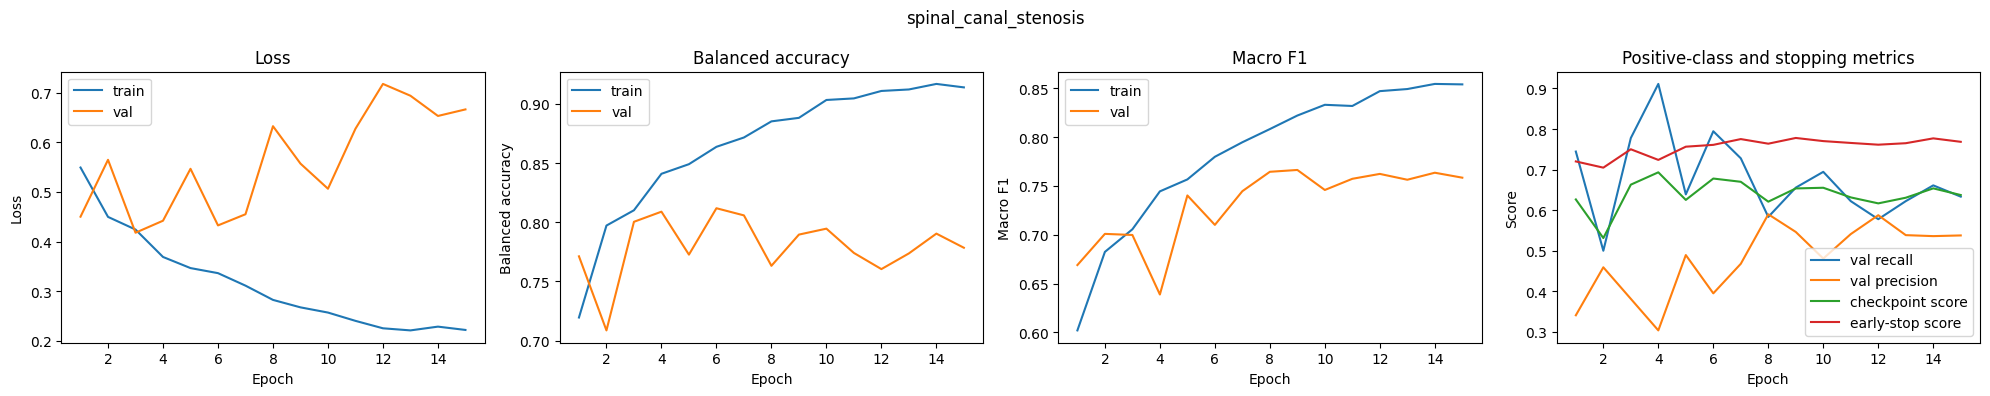


Training model: neural_foraminal_narrowing
Class counts: {'no_stenosis': np.int64(10800), 'stenosis': np.int64(2979)}
Class weights: {'no_stenosis': np.float32(0.6379), 'stenosis': np.float32(2.7752)}

Epoch 1/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.5819 | Train acc: 0.6506 | Train bal acc: 0.6867 | Train macro F1: 0.6089
Val loss: 0.5229 | Val acc: 0.6369 | Val bal acc: 0.7412 | Val macro F1: 0.6201 | Val precision: 0.3800 | Val stenosis recall: 0.9333 | Checkpoint score: 0.7216 | Early-stop score: 0.6806
Saved best model: models/models_baseline_binary_medical/neural_foraminal_narrowing_best.pt

Epoch 2/50


  0%|          | 0/430 [00:00<?, ?it/s]

...

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.2226 | Train acc: 0.9078 | Train bal acc: 0.9144 | Train macro F1: 0.8759
Val loss: 0.8581 | Val acc: 0.8010 | Val bal acc: 0.7391 | Val macro F1: 0.7290 | Val precision: 0.5575 | Val stenosis recall: 0.6252 | Checkpoint score: 0.6305 | Early-stop score: 0.7341
No early-stopping improvement for 9/6 epochs.

Epoch 15/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.2234 | Train acc: 0.9076 | Train bal acc: 0.9112 | Train macro F1: 0.8750
Val loss: 0.9240 | Val acc: 0.8044 | Val bal acc: 0.7382 | Val macro F1: 0.7308 | Val precision: 0.5660 | Val stenosis recall: 0.6163 | Checkpoint score: 0.6278 | Early-stop score: 0.7345
No early-stopping improvement for 10/6 epochs.
Early stopping at epoch 15. Best checkpoint epoch was 1 with checkpoint score 0.7216.


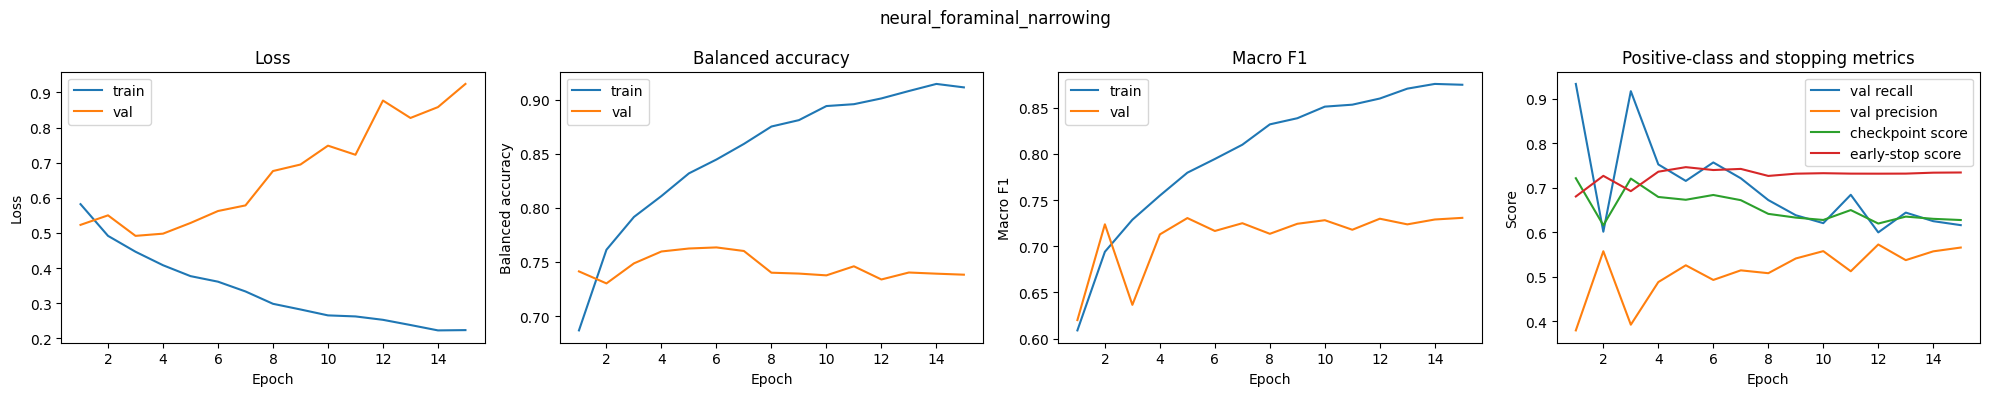


Training model: subarticular_stenosis
Class counts: {'no_stenosis': np.int64(9601), 'stenosis': np.int64(3840)}
Class weights: {'no_stenosis': np.float32(0.7), 'stenosis': np.float32(2.1002)}

Epoch 1/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.4549 | Train acc: 0.7641 | Train bal acc: 0.7804 | Train macro F1: 0.7413
Val loss: 0.4171 | Val acc: 0.8377 | Val bal acc: 0.8190 | Val macro F1: 0.8098 | Val precision: 0.7037 | Val stenosis recall: 0.7737 | Checkpoint score: 0.7648 | Early-stop score: 0.8144
Saved best model: models/models_baseline_binary_medical/subarticular_stenosis_best.pt

Epoch 2/50


  0%|          | 0/420 [00:00<?, ?it/s]

...

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.1778 | Train acc: 0.9199 | Train bal acc: 0.9279 | Train macro F1: 0.9064
Val loss: 0.7420 | Val acc: 0.8381 | Val bal acc: 0.8113 | Val macro F1: 0.8074 | Val precision: 0.7151 | Val stenosis recall: 0.7464 | Checkpoint score: 0.7515 | Early-stop score: 0.8094
No early-stopping improvement for 13/6 epochs.

Epoch 15/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.1702 | Train acc: 0.9218 | Train bal acc: 0.9287 | Train macro F1: 0.9084
Val loss: 0.7346 | Val acc: 0.8350 | Val bal acc: 0.8115 | Val macro F1: 0.8051 | Val precision: 0.7046 | Val stenosis recall: 0.7547 | Checkpoint score: 0.7533 | Early-stop score: 0.8083
No early-stopping improvement for 14/6 epochs.
Early stopping at epoch 15. Best checkpoint epoch was 6 with checkpoint score 0.7859.


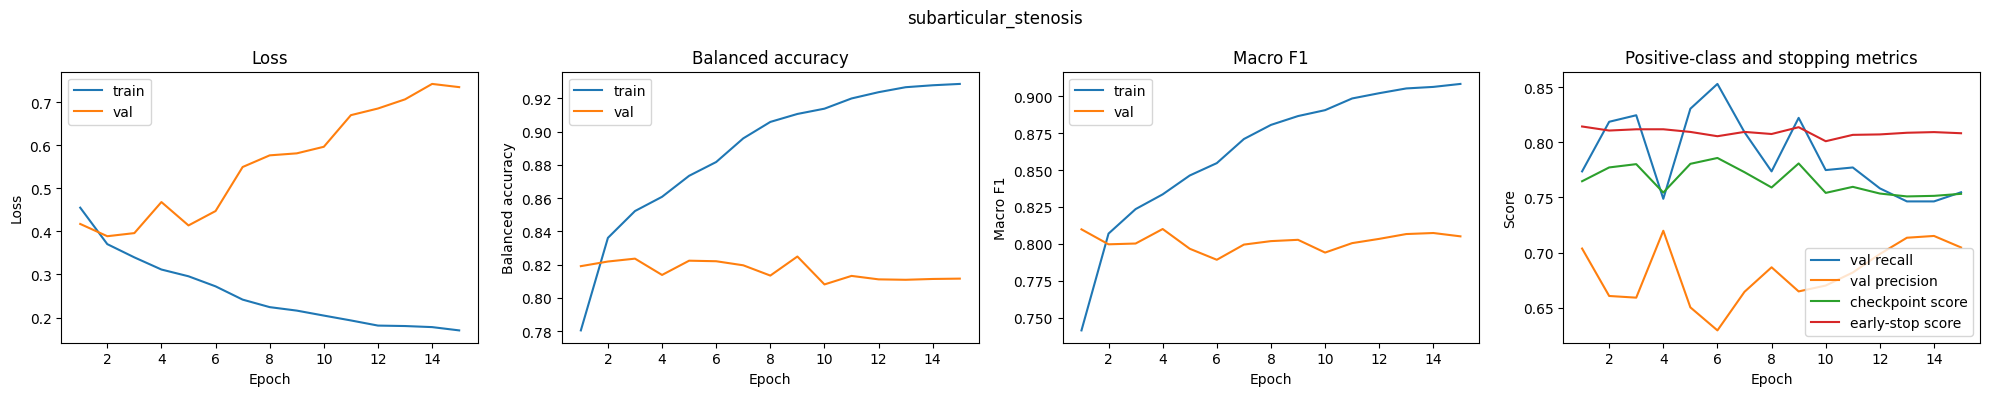

In [20]:
import gc

trained_models = {}
histories = {}

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    # Explicitly release old loaders before creating new ones.
    try:
        del train_loader
        del val_loader
    except NameError:
        pass
    gc.collect()

    train_part = model_dfs[model_name]["train"]
    val_part = model_dfs[model_name]["val"]

    if len(train_part) == 0 or len(val_part) == 0:
        print(f"Skipping {model_name}: empty train or validation set.")
        continue

    train_loader, val_loader = make_loaders(
        train_part,
        val_part,
        batch_size=BATCH_SIZE,
        use_weighted_sampler=USE_WEIGHTED_SAMPLER,
    )

    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=N_CLASSES,
        pretrained=PRETRAINED,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    criterion = make_class_weighted_loss(train_part, DEVICE)
    optimizer = make_optimizer(model)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    model, history_df = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        epochs=EPOCHS,
        min_epochs=MIN_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    trained_models[model_name] = model
    histories[model_name] = history_df

    plot_history(history_df, title=model_name)


## 15. Test evaluation


Testing model: spinal_canal_stenosis
Class counts: {'no_stenosis': np.int64(5964), 'stenosis': np.int64(856)}
Class weights: {'no_stenosis': np.float32(0.5718), 'stenosis': np.float32(4.7804)}


  0%|          | 0/46 [00:00<?, ?it/s]

Best validation threshold: 0.1
Best threshold row: {'threshold': np.float64(0.1), 'precision': 0.2174969623329283, 'recall': 0.9944444444444445, 'f1': 0.35692921236291125, 'balanced_accuracy': np.float64(0.7460521754203502), 'score': np.float64(1.2701897913902598)}


  0%|          | 0/46 [00:00<?, ?it/s]

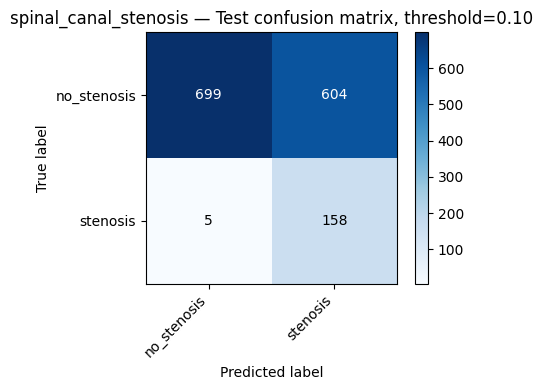

              precision    recall  f1-score   support

 no_stenosis       0.99      0.54      0.70      1303
    stenosis       0.21      0.97      0.34       163

    accuracy                           0.58      1466
   macro avg       0.60      0.75      0.52      1466
weighted avg       0.91      0.58      0.66      1466


Testing model: neural_foraminal_narrowing
Class counts: {'no_stenosis': np.int64(10800), 'stenosis': np.int64(2979)}
Class weights: {'no_stenosis': np.float32(0.6379), 'stenosis': np.float32(2.7752)}


  0%|          | 0/93 [00:00<?, ?it/s]

Best validation threshold: 0.3199999999999999
Best threshold row: {'threshold': np.float64(0.3199999999999999), 'precision': 0.3151862464183381, 'recall': 0.9777777777777777, 'f1': 0.47670639219934996, 'balanced_accuracy': np.float64(0.6744152046783626), 'score': np.float64(1.265558176997206)}


  0%|          | 0/93 [00:00<?, ?it/s]

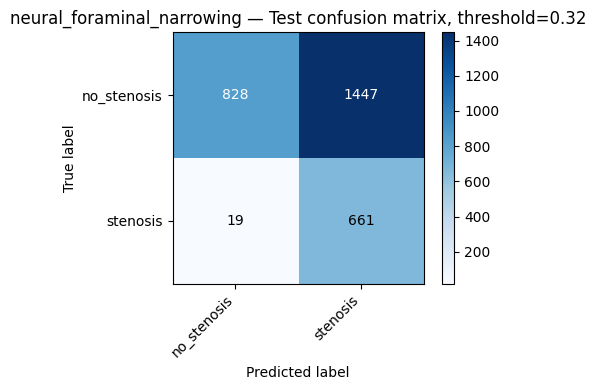

              precision    recall  f1-score   support

 no_stenosis       0.98      0.36      0.53      2275
    stenosis       0.31      0.97      0.47       680

    accuracy                           0.50      2955
   macro avg       0.65      0.67      0.50      2955
weighted avg       0.82      0.50      0.52      2955


Testing model: subarticular_stenosis
Class counts: {'no_stenosis': np.int64(9601), 'stenosis': np.int64(3840)}
Class weights: {'no_stenosis': np.float32(0.7), 'stenosis': np.float32(2.1002)}


  0%|          | 0/90 [00:00<?, ?it/s]

Best validation threshold: 0.1
Best threshold row: {'threshold': np.float64(0.1), 'precision': 0.5161917098445595, 'recall': 0.9443127962085308, 'f1': 0.6675041876046901, 'balanced_accuracy': np.float64(0.7879848004711293), 'score': np.float64(1.3081850432274855)}


  0%|          | 0/91 [00:00<?, ?it/s]

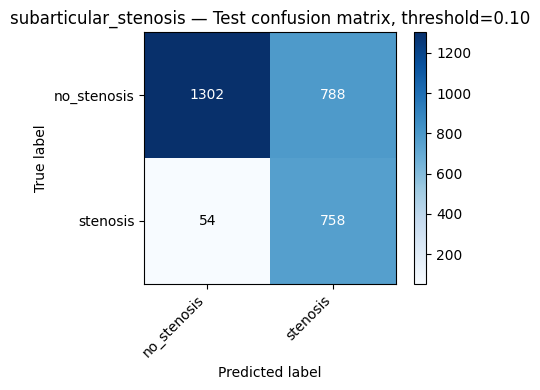

              precision    recall  f1-score   support

 no_stenosis       0.96      0.62      0.76      2090
    stenosis       0.49      0.93      0.64       812

    accuracy                           0.71      2902
   macro avg       0.73      0.78      0.70      2902
weighted avg       0.83      0.71      0.72      2902



,model,input,pretrained,use_weighted_sampler,recall_weight_multiplier,label_smoothing,hidden_dim,dropout,backbone_lr_multiplier,min_epochs,...,test_loss,test_log_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_stenosis_precision,test_stenosis_recall,test_recall_f1,n_test_rows,n_test_studies
0,spinal_canal_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.2,0.0,512,0.15,0.1,15,...,0.460468,0.659280,0.584584,0.752890,0.519092,0.207349,0.969325,0.341622,1466,297
1,neural_foraminal_narrowing,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.2,0.0,512,0.15,0.1,15,...,0.550826,0.708745,0.503892,0.668007,0.502302,0.313567,0.972059,0.474175,2955,296
2,subarticular_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.2,0.0,512,0.15,0.1,15,...,0.453796,0.473423,0.709855,0.778232,0.699288,0.490298,0.933498,0.642918,2902,297


,model,best_threshold,val_threshold_threshold,val_threshold_precision,val_threshold_recall,val_threshold_f1,val_threshold_balanced_accuracy,val_threshold_score
0,spinal_canal_stenosis,0.10,0.10,0.217497,0.994444,0.356929,0.746052,1.270190
1,neural_foraminal_narrowing,0.32,0.32,0.315186,0.977778,0.476706,0.674415,1.265558
2,subarticular_stenosis,0.10,0.10,0.516192,0.944313,0.667504,0.787985,1.308185


Saved: models/models_baseline_binary_medical/test_results_recall_balanced_pretrained.csv
Saved: models/models_baseline_binary_medical/threshold_results_pretrained.csv


In [21]:
def load_best_model(model_name):
    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=N_CLASSES,
        pretrained=PRETRAINED,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    model_path = OUTPUT_DIR / f"{model_name}_best.pt"
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    return model


test_results = []
threshold_results = []

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Testing model: {model_name}")
    print("=" * 80)

    val_part = model_dfs[model_name]["val"]
    test_part = model_dfs[model_name]["test"]

    if len(val_part) == 0 or len(test_part) == 0:
        print(f"Skipping {model_name}: empty validation or test set.")
        continue

    model = load_best_model(model_name)
    val_loader = make_test_loader(val_part, batch_size=BATCH_SIZE)
    test_loader = make_test_loader(test_part, batch_size=BATCH_SIZE)

    # Use train split for loss weights; metrics are the primary comparison.
    criterion = make_class_weighted_loss(model_dfs[model_name]["train"], DEVICE)

    val_metrics_05 = evaluate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE,
        threshold=0.5,
    )

    val_positive_probs = val_metrics_05["y_prob"][:, 1]
    best_threshold, threshold_table, best_threshold_row = find_best_threshold(
        val_metrics_05["y_true"],
        val_positive_probs,
        min_precision=MIN_PRECISION_FOR_THRESHOLD,
    )

    threshold_table.to_csv(
        OUTPUT_DIR / f"{model_name}_threshold_search.csv",
        index=False,
    )

    threshold_results.append({
        "model": model_name,
        "best_threshold": best_threshold,
        **{f"val_threshold_{k}": v for k, v in best_threshold_row.items()},
    })

    print("Best validation threshold:", best_threshold)
    print("Best threshold row:", best_threshold_row)

    metrics = evaluate_one_epoch(
        model,
        test_loader,
        criterion,
        DEVICE,
        threshold=best_threshold,
    )

    show_confusion_and_report(
        metrics["y_true"],
        metrics["y_pred"],
        class_names=TARGET_NAMES,
        title=f"{model_name} — Test confusion matrix, threshold={best_threshold:.2f}",
    )

    row = {
        "model": model_name,
        "input": "full_image_grayscale_repeated_3ch_plus_metadata",
        "pretrained": PRETRAINED,
        "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
        "recall_weight_multiplier": RECALL_WEIGHT_MULTIPLIER,
        "label_smoothing": LABEL_SMOOTHING,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "backbone_lr_multiplier": BACKBONE_LR_MULTIPLIER,
        "min_epochs": MIN_EPOCHS,
        "patience": PATIENCE,
        "best_validation_threshold": best_threshold,
        "test_loss": metrics["loss"],
        "test_log_loss": metrics["log_loss"],
        "test_accuracy": metrics["accuracy"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_stenosis_precision": metrics["stenosis_precision"],
        "test_stenosis_recall": metrics["stenosis_recall"],
        "test_recall_f1": metrics["recall_f1"],
        "n_test_rows": len(test_part),
        "n_test_studies": test_part["study_id"].nunique(),
    }

    test_results.append(row)

results_table = pd.DataFrame(test_results)
threshold_results_table = pd.DataFrame(threshold_results)

display(results_table)
display(threshold_results_table)

suffix = "pretrained" if PRETRAINED else "scratch"
results_path = OUTPUT_DIR / f"test_results_recall_balanced_{suffix}.csv"
thresholds_path = OUTPUT_DIR / f"threshold_results_{suffix}.csv"

results_table.to_csv(results_path, index=False)
threshold_results_table.to_csv(thresholds_path, index=False)

print("Saved:", results_path)
print("Saved:", thresholds_path)
